In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# 1. Configuration
n_users = 5000
np.random.seed(42)

# 2. Generating raw columns
data = {
    'User_ID': np.arange(1001, 1001 + n_users),
    'Age': np.random.randint(18, 55, n_users),
    'Gender': np.random.choice(['Male', 'Female'], n_users),
    'City_Tier': np.random.choice([1, 2, 3], n_users, p=[0.5, 0.3, 0.2]),
    'Warehouse_To_Home_Distance': np.random.randint(5, 40, n_users),
    'Preferred_Login_Device': np.random.choice(['Mobile App', 'Computer'], n_users),
    'Preferred_Payment_Mode': np.random.choice(['UPI', 'Debit Card', 'Credit Card', 'COD'], n_users),
    'Tenure_Months': np.random.randint(0, 48, n_users),
    'Order_Count_Last_Month': np.random.randint(0, 20, n_users),
    'Day_Since_Last_Order': np.random.randint(0, 65, n_users),
    'Satisfaction_Score': np.random.randint(1, 6, n_users),
    'Complain_Logged': np.random.choice([0, 1], n_users, p=[0.75, 0.25]),
    'Cashback_Amount': np.round(np.random.uniform(50, 500, n_users), 2)
}

df = pd.DataFrame(data)

# 3. Applying Business Logic for Churn
df['Churn'] = 0
df.loc[(df['Day_Since_Last_Order'] > 30), 'Churn'] = 1
df.loc[(df['Satisfaction_Score'] <= 2) & (df['Complain_Logged'] == 1), 'Churn'] = 1

# 4. Save and Download
df.to_csv('Zomato_Churn_Data.csv', index=False)
files.download('Zomato_Churn_Data.csv')

print("--- Data Generation Complete ---")
print(f"Total Churned Users: {df['Churn'].sum()}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--- Data Generation Complete ---
Total Churned Users: 2865


In [ ]:
# 1. Check basic info
print(df.info())

# 2. Calculate Churn Rate (Key Business Metric)
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# 3. See which features are most common in churned users
print("\nAverage Stats for Churned vs Retained:")
print(df.groupby('Churn')[['Satisfaction_Score', 'Day_Since_Last_Order', 'Cashback_Amount']].mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     5000 non-null   int64  
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   City_Tier                   5000 non-null   int64  
 4   Warehouse_To_Home_Distance  5000 non-null   int64  
 5   Preferred_Login_Device      5000 non-null   object 
 6   Preferred_Payment_Mode      5000 non-null   object 
 7   Tenure_Months               5000 non-null   int64  
 8   Order_Count_Last_Month      5000 non-null   int64  
 9   Day_Since_Last_Order        5000 non-null   int64  
 10  Satisfaction_Score          5000 non-null   int64  
 11  Complain_Logged             5000 non-null   int64  
 12  Cashback_Amount             5000 non-null   float64
 13  Churn                       5000 

/tmp/ipykernel_9166/3896464074.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn', y='Satisfaction_Score', data=df, palette='viridis')


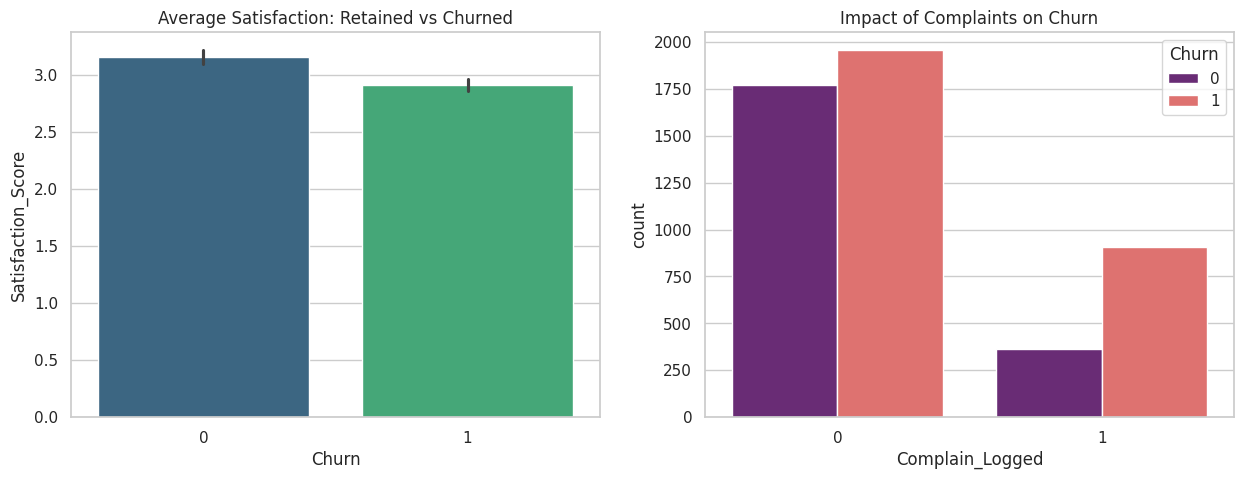

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set(style="whitegrid")

# Create a figure with two subplots
plt.figure(figsize=(15, 5))

# Plot 1: Satisfaction vs Churn
plt.subplot(1, 2, 1)
sns.barplot(x='Churn', y='Satisfaction_Score', data=df, palette='viridis')
plt.title('Average Satisfaction: Retained vs Churned')

# Plot 2: Complaints vs Churn
plt.subplot(1, 2, 2)
sns.countplot(x='Complain_Logged', hue='Churn', data=df, palette='magma')
plt.title('Impact of Complaints on Churn')

plt.show()

<Axes: xlabel='Churn', ylabel='Satisfaction_Score'>

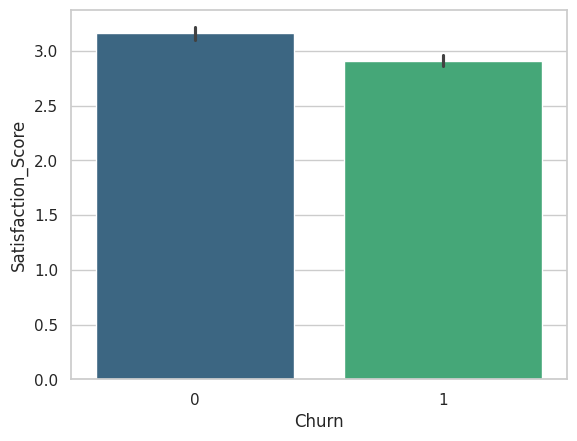

In [ ]:
sns.barplot(x='Churn', y='Satisfaction_Score', data=df, hue='Churn', palette='viridis', legend=False)